# ChurnSense — Phase 1
## Multi-Class Churn Prediction with Cost-Sensitive Learning

**Business problem:** A telecom loses ~26% of customers annually to churn. Treating this as a binary Yes/No problem discards urgency information. A customer *about* to leave needs a different response than one who churned last month.

**What ChurnSense does differently:**
- Classifies every customer into **4 risk tiers** — Loyal → At-Risk → Critical → Will-Churn
- Trains with a **business cost matrix** so the model minimises lost revenue, not just error rate
- Produces **per-tier intervention recommendations** with ROI estimates

| | |
|---|---|
| **Dataset** | IBM Telco Customer Churn (7,043 customers) |
| **Model** | XGBoost + SMOTE (cost-sensitive, multi-class) |
| **Target** | 4 risk tiers derived from the Churn Score column |
| **Phase 2** | Temporal (30/60/90-day) predictions · ROI optimizer · Live Streamlit dashboard |

---


## 1  Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap
import joblib
import os
import warnings

warnings.filterwarnings('ignore')
os.makedirs('outputs/plots', exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
})
sns.set_style('whitegrid')

CLASS_NAMES  = ['Loyal', 'At-Risk', 'Critical', 'Will-Churn']
CLASS_COLORS = ['#2a78d6', '#1baf7a', '#eda100', '#e34948']
CLASS_MAP    = {0: 'Loyal', 1: 'At-Risk', 2: 'Critical', 3: 'Will-Churn'}

print('Setup complete.')


Setup complete.


## 2  Load & Audit the Data

In [2]:
df = pd.read_excel('data/Telco_customer_churn.xlsx')

# Total Charges is sometimes imported as object with empty strings
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'].fillna(df['Monthly Charges'], inplace=True)

print(f"Shape      : {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"Churn rate : {df['Churn Value'].mean():.1%}  ({int(df['Churn Value'].sum()):,} churned)")
print(f"Churn Score: min={df['Churn Score'].min()},  max={df['Churn Score'].max()},  mean={df['Churn Score'].mean():.1f}")

missing = df.isnull().sum()
missing = missing[missing > 0]
print("\nMissing values:")
print(missing.to_string() if len(missing) > 0 else "  None")

df.head(3)


Shape      : 7,043 rows  x  33 columns
Churn rate : 26.5%  (1,869 churned)
Churn Score: min=5,  max=100,  mean=58.7

Missing values:
Churn Reason    5174


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved


## 3  Exploratory Data Analysis

Each chart ends with a **Business Insight** — the takeaway a stakeholder actually cares about.


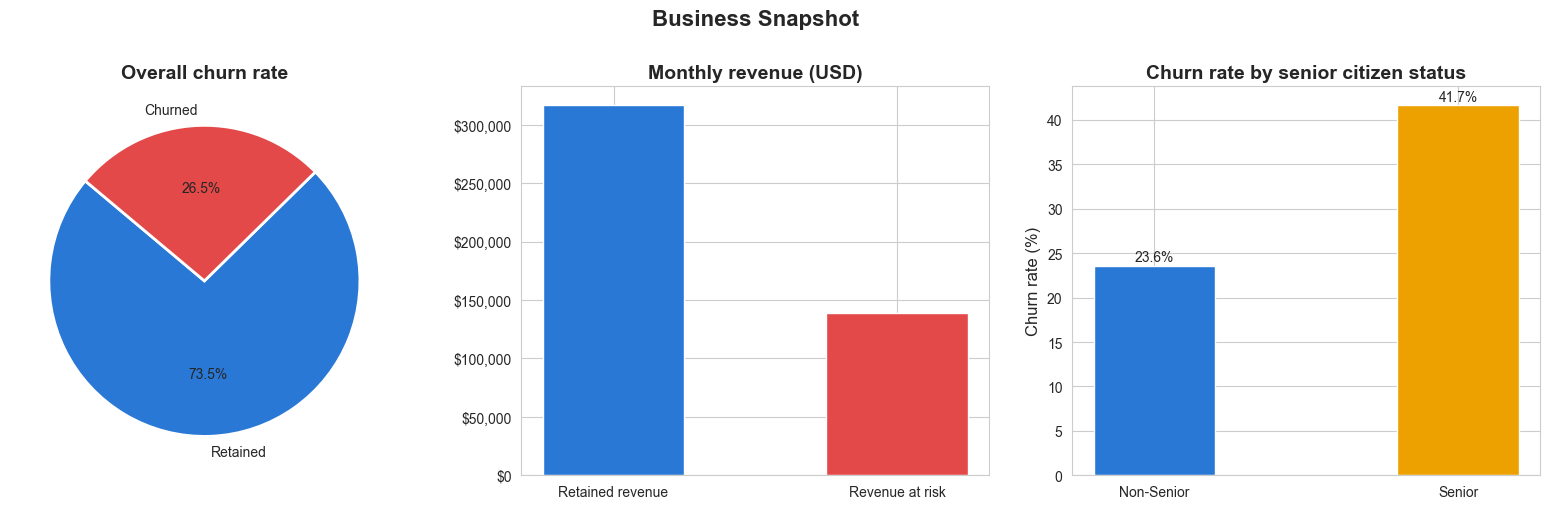


Business Insight: 1,869 churned customers = $139,131/month in lost revenue.


In [3]:
# ── Chart 1: High-level snapshot ────────────────────────────
churned      = int(df['Churn Value'].sum())
retained     = len(df) - churned
rev_at_risk  = df[df['Churn Value'] == 1]['Monthly Charges'].sum()
rev_retained = df[df['Churn Value'] == 0]['Monthly Charges'].sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].pie([retained, churned],
            labels=['Retained', 'Churned'],
            colors=['#2a78d6', '#e34948'],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Overall churn rate')

axes[1].bar(['Retained revenue', 'Revenue at risk'],
            [rev_retained, rev_at_risk],
            color=['#2a78d6', '#e34948'], width=0.5, edgecolor='white')
axes[1].set_title('Monthly revenue (USD)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

if df['Senior Citizen'].dtype == object:
    sc_map = {'Yes': 1, 'No': 0}
    df['_sc'] = df['Senior Citizen'].map(sc_map).fillna(df['Senior Citizen'])
else:
    df['_sc'] = df['Senior Citizen']
sc_rate = df.groupby('_sc')['Churn Value'].mean() * 100
axes[2].bar(['Non-Senior', 'Senior'], sc_rate.values,
            color=['#2a78d6', '#eda100'], width=0.4, edgecolor='white')
axes[2].set_title('Churn rate by senior citizen status')
axes[2].set_ylabel('Churn rate (%)')
for i, v in enumerate(sc_rate.values):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.suptitle('Business Snapshot', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/plots/01_snapshot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBusiness Insight: {churned:,} churned customers = ${rev_at_risk:,.0f}/month in lost revenue.")


In [ ]:
# ── Chart 2: Contract type — strongest churn driver ─────────
contract_churn = (df.groupby('Contract')['Churn Value']
                    .agg(churn_rate='mean', customers='count')
                    .reset_index()
                    .sort_values('churn_rate', ascending=True))

fig, ax = plt.subplots(figsize=(10, 4))
bar_cols = ['#2a78d6', '#eda100', '#e34948'][:len(contract_churn)]
bars = ax.barh(contract_churn['Contract'],
               contract_churn['churn_rate'] * 100,
               color=bar_cols, edgecolor='white', height=0.5)

avg = df['Churn Value'].mean() * 100
ax.axvline(avg, linestyle='--', color='gray', alpha=0.6, label=f'Avg ({avg:.1f}%)')

for bar, (_, row) in zip(bars, contract_churn.iterrows()):
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"{row['churn_rate']:.1%}  ({row['customers']:,} customers)",
            va='center', fontsize=11)

ax.set_xlim(0, 65)
ax.set_xlabel('Churn rate (%)')
ax.set_title('Churn rate by contract type')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/plots/02_contract.png', dpi=150, bbox_inches='tight')
plt.show()

print("Business Insight: Month-to-month customers churn at 3-4x the rate of two-year holders.")
print("Converting even 10% of month-to-month customers to annual contracts = significant revenue recovery.")


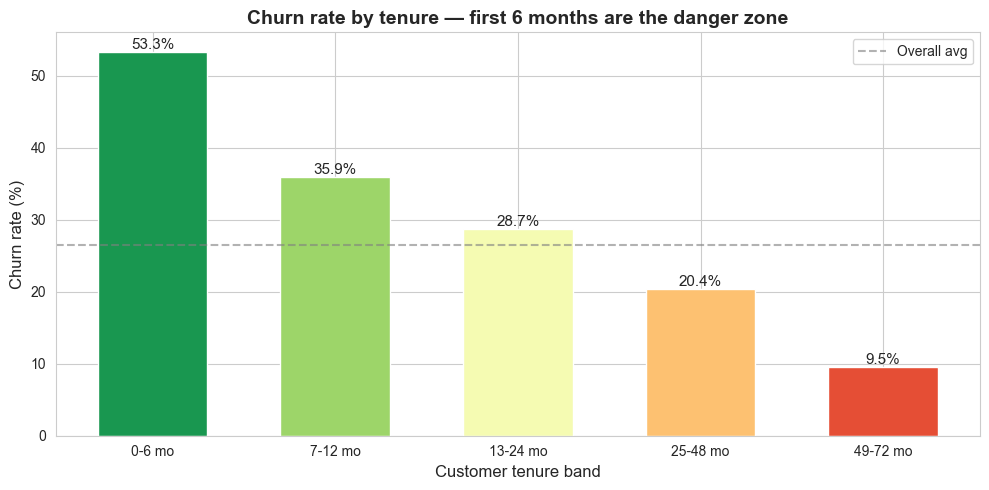

Business Insight: Churn risk is highest in months 0-6.
An early-engagement programme for new customers would have the highest ROI of any single retention initiative.


In [4]:
# ── Chart 3: Tenure vs churn ─────────────────────────────────
df['Tenure Group'] = pd.cut(
    df['Tenure Months'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0-6 mo', '7-12 mo', '13-24 mo', '25-48 mo', '49-72 mo']
)
tenure_churn = df.groupby('Tenure Group', observed=False)['Churn Value'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
cmap_colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.85, len(tenure_churn)))
bars = ax.bar(tenure_churn.index, tenure_churn.values,
              color=cmap_colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, tenure_churn.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4,
            f'{val:.1f}%', ha='center', fontsize=11)
ax.axhline(df['Churn Value'].mean() * 100, linestyle='--',
           color='gray', alpha=0.6, label='Overall avg')
ax.set_ylabel('Churn rate (%)')
ax.set_xlabel('Customer tenure band')
ax.set_title('Churn rate by tenure — first 6 months are the danger zone')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/plots/03_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

print("Business Insight: Churn risk is highest in months 0-6.")
print("An early-engagement programme for new customers would have the highest ROI of any single retention initiative.")


In [ ]:
# ── Chart 4: Monthly charges distribution by churn status ────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for churn_val, label, color in [(0, 'Retained', '#2a78d6'), (1, 'Churned', '#e34948')]:
    subset = df[df['Churn Value'] == churn_val]['Monthly Charges']
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)
axes[0].set_xlabel('Monthly Charges (USD)')
axes[0].set_ylabel('Density')
axes[0].set_title('Monthly charges distribution by churn status')
axes[0].legend()

churn_labels = ['No', 'Yes']
data_by_churn = [df[df['Churn Label'] == lbl]['Monthly Charges'].values
                 for lbl in churn_labels]
bp = axes[1].boxplot(data_by_churn, labels=['Retained', 'Churned'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2a78d6', '#e34948']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp['medians']:
    median.set_color('white')
    median.set_linewidth(2)
axes[1].set_title('Monthly charges — boxplot by churn status')
axes[1].set_ylabel('Monthly Charges (USD)')

plt.tight_layout()
plt.savefig('outputs/plots/04_charges.png', dpi=150, bbox_inches='tight')
plt.show()

med_churned  = df[df['Churn Value'] == 1]['Monthly Charges'].median()
med_retained = df[df['Churn Value'] == 0]['Monthly Charges'].median()
print(f"Business Insight: Churned customers pay ${med_churned:.0f}/mo median vs ${med_retained:.0f}/mo for retained.")
print("High-spending customers are more price-sensitive — they need value-add bundles, not just discounts.")


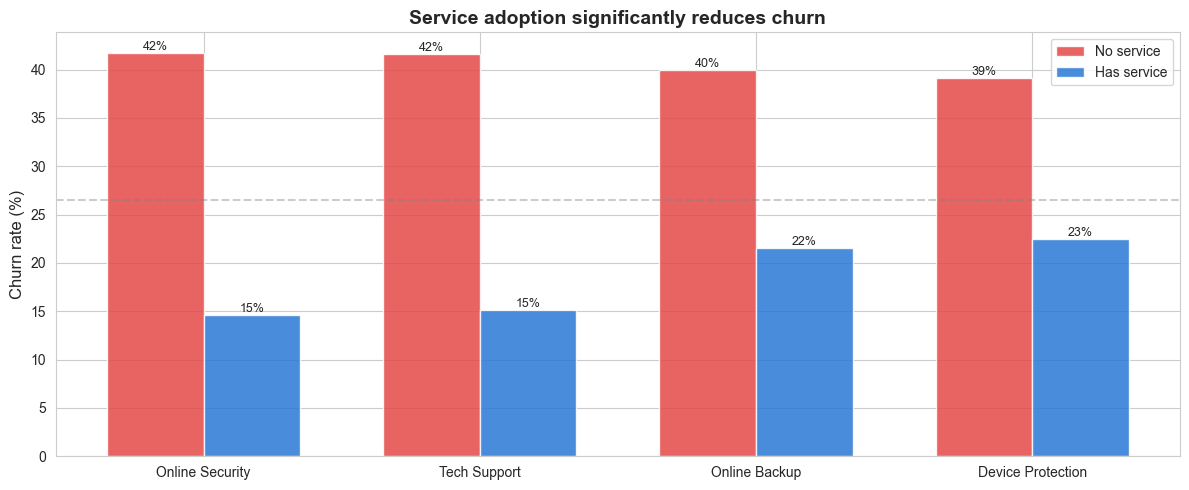

Business Insight: Customers without Online Security or Tech Support churn at ~2x the rate of those with it.
Bundling protective services into at-risk customer offers is a defensible, testable retention tactic.


In [5]:
# ── Chart 5: Service adoption vs churn ──────────────────────
services = ['Online Security', 'Tech Support', 'Online Backup', 'Device Protection']
no_rates, yes_rates = [], []
for svc in services:
    no_rates.append(df[df[svc] == 'No']['Churn Value'].mean() * 100)
    yes_rates.append(df[df[svc] == 'Yes']['Churn Value'].mean() * 100)

x = np.arange(len(services))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w / 2, no_rates,  w, label='No service',  color='#e34948', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w / 2, yes_rates, w, label='Has service', color='#2a78d6', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(services)
ax.set_ylabel('Churn rate (%)')
ax.set_title('Service adoption significantly reduces churn')
ax.legend()
ax.axhline(df['Churn Value'].mean() * 100, linestyle='--', color='gray', alpha=0.4)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3, f'{bar.get_height():.0f}%', ha='center', fontsize=9)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3, f'{bar.get_height():.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/plots/05_services.png', dpi=150, bbox_inches='tight')
plt.show()

print("Business Insight: Customers without Online Security or Tech Support churn at ~2x the rate of those with it.")
print("Bundling protective services into at-risk customer offers is a defensible, testable retention tactic.")


In [ ]:
# ── Chart 6: Churn Score — the basis of our 4-class label ───
boundaries = [
    (0,  25,  '#2a78d6', 'Loyal'),
    (25, 50,  '#1baf7a', 'At-Risk'),
    (50, 75,  '#eda100', 'Critical'),
    (75, 100, '#e34948', 'Will-Churn'),
]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['Churn Score'], bins=50, color='#ccc', alpha=0.4, edgecolor='white')
for lo, hi, color, label in boundaries:
    mask = (df['Churn Score'] > lo) & (df['Churn Score'] <= hi)
    ax.hist(df.loc[mask, 'Churn Score'], bins=20, color=color,
            alpha=0.75, edgecolor='white', label=f'{label}  ({mask.sum():,})')
    ax.axvline(hi, linestyle='--', color='gray', alpha=0.35, linewidth=1)

# Add class labels at top — called after all histograms so ylim is settled
ymax = ax.get_ylim()[1]
for lo, hi, color, label in boundaries:
    ax.text((lo + hi) / 2, ymax * 0.90, label,
            ha='center', fontsize=11, fontweight='bold', color=color)

ax.set_xlabel('Churn Score (0-100)')
ax.set_ylabel('Number of customers')
ax.set_title('Churn Score distribution — this column becomes our 4-class target label')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('outputs/plots/06_churn_score.png', dpi=150, bbox_inches='tight')
plt.show()

print("Class breakdown from Churn Score:")
for lo, hi, _, label in boundaries:
    n = ((df['Churn Score'] > lo) & (df['Churn Score'] <= hi)).sum()
    print(f"  {label:12s} ({lo:>2}-{hi:>3}): {n:>5,} customers  ({n/len(df):.1%})")


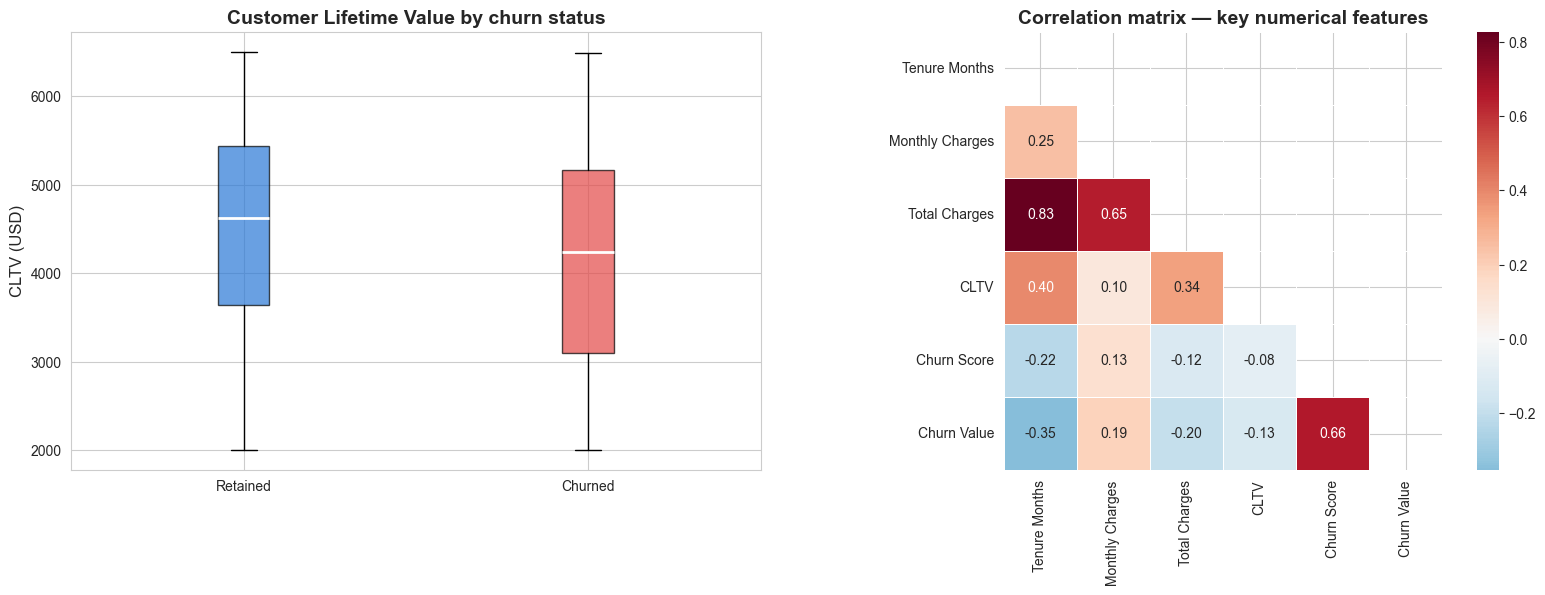

Business Insight: Total lifetime value tied to churned customers: $7,755,256
Churn Score is strongly correlated with Churn Value — confirms it is a reliable basis for our 4-class label.


In [6]:
# ── Chart 7: CLTV analysis + correlation heatmap ─────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

data_cltv = [df[df['Churn Label'] == lbl]['CLTV'].values for lbl in ['No', 'Yes']]
bp = axes[0].boxplot(data_cltv, labels=['Retained', 'Churned'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2a78d6', '#e34948']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp['medians']:
    median.set_color('white')
    median.set_linewidth(2)
axes[0].set_title('Customer Lifetime Value by churn status')
axes[0].set_ylabel('CLTV (USD)')

num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Churn Score', 'Churn Value']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[1], square=True,
            annot_kws={'size': 10}, linewidths=0.5)
axes[1].set_title('Correlation matrix — key numerical features')

plt.tight_layout()
plt.savefig('outputs/plots/07_cltv_corr.png', dpi=150, bbox_inches='tight')
plt.show()

total_cltv_lost = df[df['Churn Value'] == 1]['CLTV'].sum()
print(f"Business Insight: Total lifetime value tied to churned customers: ${total_cltv_lost:,.0f}")
print("Churn Score is strongly correlated with Churn Value — confirms it is a reliable basis for our 4-class label.")


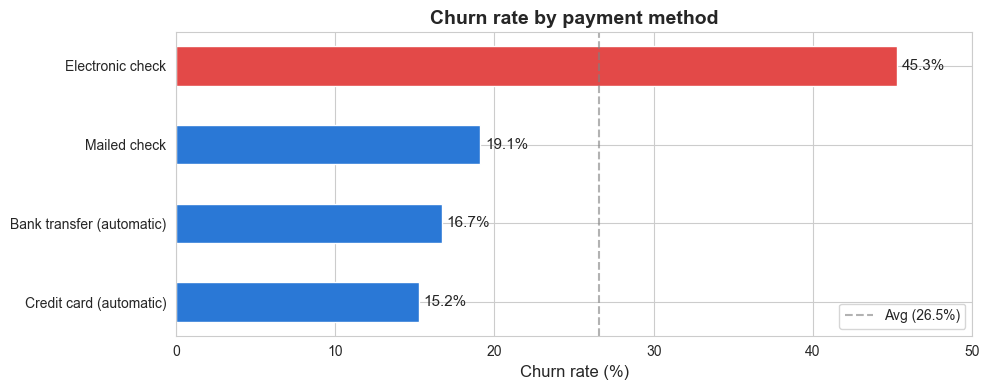

Business Insight: Electronic check users churn at the highest rate.
Encouraging auto-pay adoption (credit card / bank transfer) reduces churn passively.


In [7]:
# ── Chart 8: Payment method vs churn ─────────────────────────
pm_churn = (df.groupby('Payment Method')['Churn Value']
              .mean()
              .sort_values(ascending=True) * 100)

fig, ax = plt.subplots(figsize=(10, 4))
avg_pct = df['Churn Value'].mean() * 100
bar_colors = ['#e34948' if v > avg_pct else '#2a78d6' for v in pm_churn.values]
bars = ax.barh(pm_churn.index, pm_churn.values, color=bar_colors, edgecolor='white', height=0.5)
ax.axvline(avg_pct, linestyle='--', color='gray', alpha=0.6, label=f'Avg ({avg_pct:.1f}%)')
for bar in bars:
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}%', va='center', fontsize=11)
ax.set_xlim(0, 50)
ax.set_xlabel('Churn rate (%)')
ax.set_title('Churn rate by payment method')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/plots/08_payment.png', dpi=150, bbox_inches='tight')
plt.show()

print("Business Insight: Electronic check users churn at the highest rate.")
print("Encouraging auto-pay adoption (credit card / bank transfer) reduces churn passively.")


## 4  Customer Segmentation — K-Means

Segment customers by financial behaviour and engagement. Phase 2 uses these segments to personalise intervention strategies per risk tier.


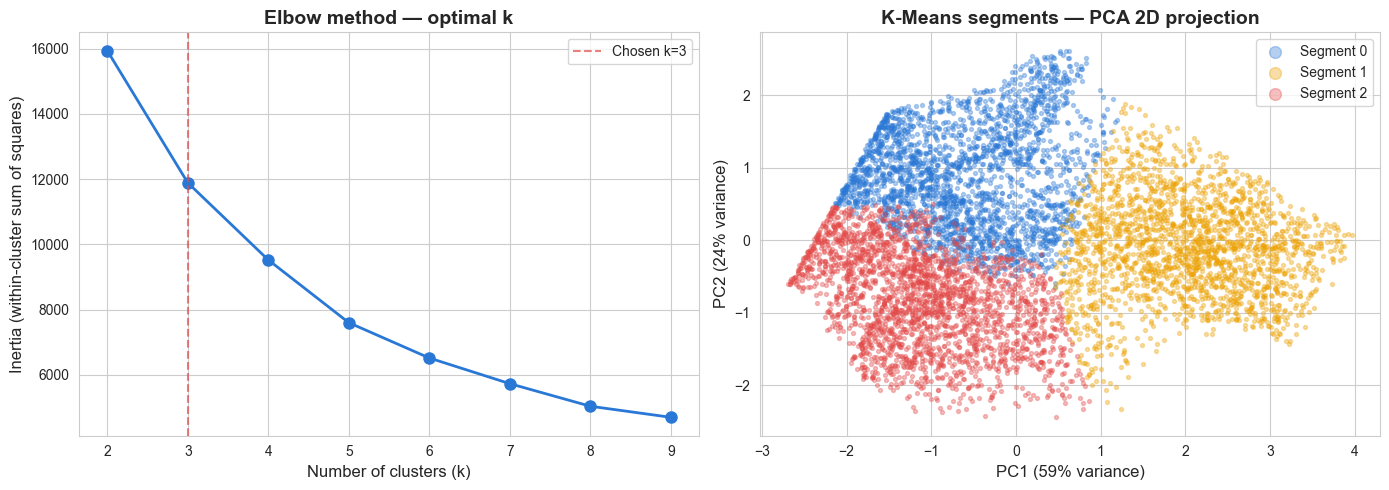

In [8]:
# ── Elbow method to find optimal k ──────────────────────────
cluster_features = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
X_cluster = df[cluster_features].copy()
scaler_cluster = StandardScaler()
X_scaled  = scaler_cluster.fit_transform(X_cluster)

inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(2, 10), inertias, 'o-', color='#2a78d6', linewidth=2, markersize=8)
axes[0].axvline(3, linestyle='--', color='#e34948', alpha=0.7, label='Chosen k=3')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow method — optimal k')
axes[0].legend()

# ── Fit k=3 ──────────────────────────────────────────────────
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Segment'] = km.fit_predict(X_scaled)

# ── PCA 2D projection ────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
seg_palette = ['#2a78d6', '#eda100', '#e34948']
for seg, color in enumerate(seg_palette):
    mask = df['Segment'] == seg
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, alpha=0.35, s=8, label=f'Segment {seg}')
axes[1].set_title('K-Means segments — PCA 2D projection')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)')
axes[1].legend(markerscale=3)
plt.tight_layout()
plt.savefig('outputs/plots/09_segments.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Profile and name each segment ───────────────────────────
seg_profile = df.groupby('Segment').agg(
    customers  = ('Segment', 'count'),
    avg_tenure = ('Tenure Months', 'mean'),
    avg_monthly= ('Monthly Charges', 'mean'),
    avg_cltv   = ('CLTV', 'mean'),
    churn_rate = ('Churn Value', 'mean'),
).round(2)
print(seg_profile.to_string())

# Name by churn-rate rank:
# rank 1 (lowest churn) = Loyal Premium
# rank 2 = Price-Sensitive Risk
# rank 3 (highest churn) = New Unstable
churn_rank = seg_profile['churn_rate'].rank().astype(int)
seg_names  = {}
rank_to_name = {1: 'Loyal Premium', 2: 'Price-Sensitive Risk', 3: 'New Unstable'}
for seg in range(3):
    seg_names[seg] = rank_to_name[churn_rank[seg]]

df['Segment Name'] = df['Segment'].map(seg_names)
print("\nSegment names assigned:", seg_names)

fig, ax = plt.subplots(figsize=(10, 4))
for i, (seg, name) in enumerate(seg_names.items()):
    row = seg_profile.loc[seg]
    ax.barh(name, row['churn_rate'] * 100,
            color=seg_palette[seg], alpha=0.85, edgecolor='white', height=0.4)
    ax.text(row['churn_rate'] * 100 + 0.3, i,
            f"{row['churn_rate']:.1%}  |  {row['customers']:.0f} customers  |  ${row['avg_monthly']:.0f}/mo avg",
            va='center', fontsize=11)
ax.set_xlabel('Churn rate (%)')
ax.set_title('Segment profiles — churn rate and size')
ax.set_xlim(0, 75)
plt.tight_layout()
plt.savefig('outputs/plots/10_segment_profiles.png', dpi=150, bbox_inches='tight')
plt.show()


## 5  4-Class Target Engineering

The Telco dataset includes a **Churn Score** column (0-100) — a pre-computed risk signal. We use it to define four urgency tiers instead of a binary label.

| Class | Score range | Meaning | Default action |
|---|---|---|---|
| **0 — Loyal** | 0-25 | Low risk, long-term | Loyalty rewards |
| **1 — At-Risk** | 26-50 | Early warning signs | Re-engagement email |
| **2 — Critical** | 51-75 | High risk, still reachable | Personal call + offer |
| **3 — Will-Churn** | 76-100 | Imminent churners | Urgent: immediate high-value offer |

> **Why this matters:** a model that predicts the *urgency* of churn is more actionable than one that predicts the binary *fact* of churn.


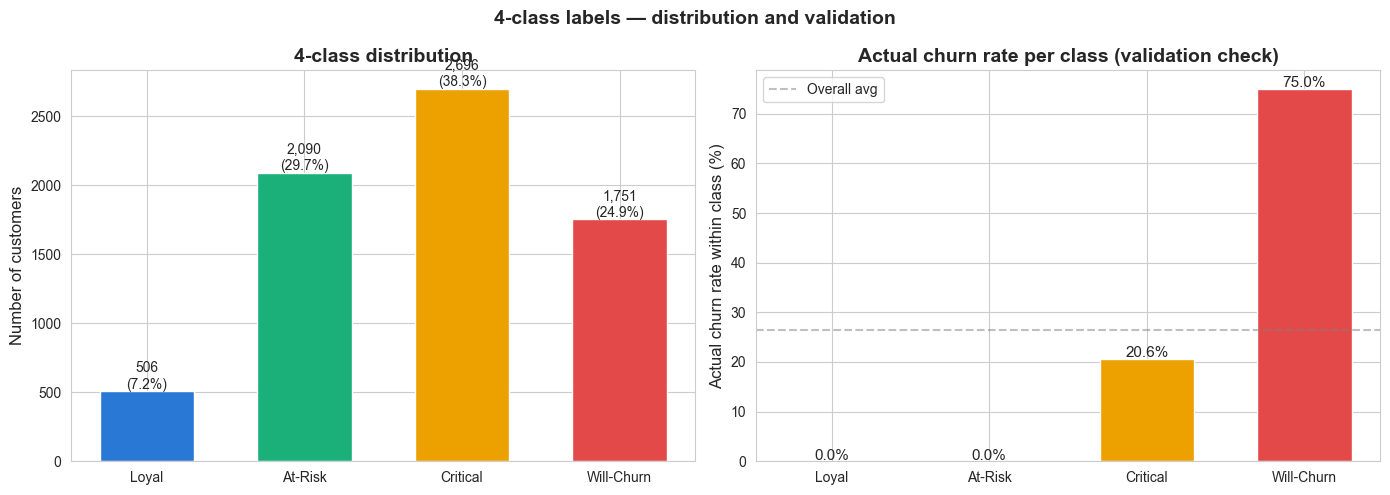

Label validation — actual churn rate should increase left to right:
  Loyal       : 0.0% actual churn rate within class
  At-Risk     : 0.0% actual churn rate within class
  Critical    : 20.6% actual churn rate within class
  Will-Churn  : 75.0% actual churn rate within class


In [9]:
# ── Assign 4-class labels ────────────────────────────────────
def assign_class(score):
    if score <= 25:    return 0  # Loyal
    elif score <= 50:  return 1  # At-Risk
    elif score <= 75:  return 2  # Critical
    else:              return 3  # Will-Churn

df['Churn Class']      = df['Churn Score'].apply(assign_class)
df['Churn Class Name'] = df['Churn Class'].map(CLASS_MAP)

# ── Validate: actual churn rate must increase class 0 → 3 ───
actual_rates = {cls: df[df['Churn Class'] == cls]['Churn Value'].mean()
                for cls in range(4)}

class_counts = df['Churn Class Name'].value_counts().reindex(CLASS_NAMES)
rates_ordered = [actual_rates[i] * 100 for i in range(4)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(CLASS_NAMES, class_counts.values,
            color=CLASS_COLORS, edgecolor='white', width=0.6)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 20, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=10)
axes[0].set_title('4-class distribution')
axes[0].set_ylabel('Number of customers')

axes[1].bar(CLASS_NAMES, rates_ordered,
            color=CLASS_COLORS, edgecolor='white', width=0.6)
for i, v in enumerate(rates_ordered):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11)
axes[1].axhline(df['Churn Value'].mean() * 100, linestyle='--',
                color='gray', alpha=0.5, label='Overall avg')
axes[1].set_title('Actual churn rate per class (validation check)')
axes[1].set_ylabel('Actual churn rate within class (%)')
axes[1].legend()

plt.suptitle('4-class labels — distribution and validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/11_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Label validation — actual churn rate should increase left to right:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:12s}: {actual_rates[i]:.1%} actual churn rate within class")


## 6  Feature Engineering & Preprocessing

In [10]:
# ── Drop leakage and irrelevant columns ─────────────────────
LEAKAGE = ['Churn Label', 'Churn Value', 'Churn Score', 'Churn Reason', 'Churn Class Name']
GEO     = ['CustomerID', 'Count', 'Country', 'State', 'City',
           'Zip Code', 'Lat Long', 'Latitude', 'Longitude']
DERIVED = ['Segment', 'Segment Name', 'Tenure Group', '_sc']

drop_cols = [c for c in LEAKAGE + GEO + DERIVED if c in df.columns]
df_model  = df.drop(columns=drop_cols).copy()

# ── Engineered features ──────────────────────────────────────
# Charge-per-tenure: approximates price sensitivity relative to relationship length
df_model['Charge per Tenure'] = (df_model['Monthly Charges'] /
                                  (df_model['Tenure Months'] + 1))

# Revenue share: customer's spend relative to the highest-paying customer
df_model['Revenue Share'] = (df_model['Monthly Charges'] /
                               df_model['Monthly Charges'].max())

# Service count: how embedded the customer is
svc_cols = [c for c in ['Online Security', 'Online Backup', 'Device Protection',
                         'Tech Support', 'Streaming TV', 'Streaming Movies']
            if c in df_model.columns]
df_model['Service Count'] = (df_model[svc_cols] == 'Yes').sum(axis=1)

# ── Encode categoricals ──────────────────────────────────────
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
le_dict  = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col]  = le

TARGET   = 'Churn Class'
FEATURES = [c for c in df_model.columns if c != TARGET]

print(f"Feature count : {len(FEATURES)}")
print(f"New features  : Charge per Tenure, Revenue Share, Service Count")
print(f"Encoded cols  : {cat_cols}")
df_model[FEATURES[:6]].head(3)


Feature count : 23
New features  : Charge per Tenure, Revenue Share, Service Count
Encoded cols  : ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service
0,1,0,0,0,2,1
1,0,0,0,1,2,1
2,0,0,0,1,8,1


In [12]:
# ── Train / test split + SMOTE ───────────────────────────────
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Train before SMOTE : {len(X_train):,}")
print(f"Train after SMOTE  : {len(X_train_res):,}")
print(f"Test set           : {len(X_test):,}")
print("\nClass distribution after SMOTE:")
unique_cls, counts_cls = np.unique(y_train_res, return_counts=True)
for cls, cnt in zip(unique_cls, counts_cls):
    print(f"  {CLASS_MAP[cls]:14s}: {cnt:,}")


Train before SMOTE : 5,634
Train after SMOTE  : 8,624
Test set           : 1,409

Class distribution after SMOTE:
  Loyal         : 2,156
  At-Risk       : 2,156
  Critical      : 2,156
  Will-Churn    : 2,156


## 7  Business Cost Matrix

Standard models minimise prediction error equally across all mistakes. We minimise **revenue loss** by telling XGBoost that some mistakes cost far more than others.

- **Diagonal** = correct prediction ($0 cost)
- Missing a **Will-Churn** customer and calling them Loyal = **$200** — you lose the customer entirely
- Falsely flagging a **Loyal** customer as Will-Churn = **$60** — wasted intervention budget

XGBoost receives these costs as `sample_weight`, so it learns to penalise expensive mistakes more heavily during training.


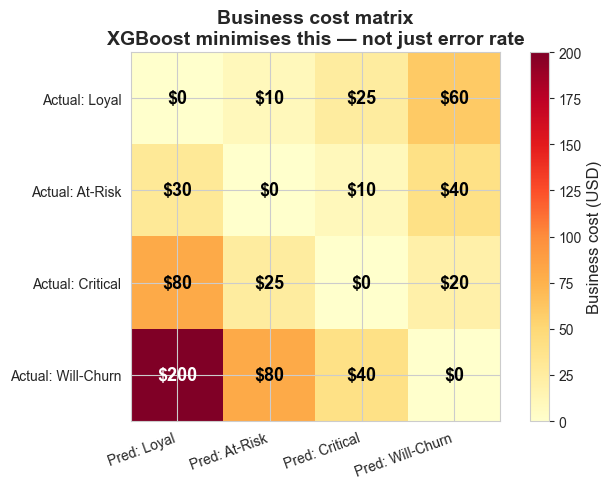

Sample weight summary (higher = model pays more attention to this class):
  Loyal         : avg misclassification cost $31.7  =>  weight 31.7
  At-Risk       : avg misclassification cost $26.7  =>  weight 26.7
  Critical      : avg misclassification cost $41.7  =>  weight 41.7
  Will-Churn    : avg misclassification cost $106.7  =>  weight 106.7


In [13]:
# ── Define cost matrix ───────────────────────────────────────
#                     Pred:Loyal  At-Risk  Critical  Will-Churn
COST_MATRIX = np.array([
    [  0,  10,  25,  60],  # Actual: Loyal
    [ 30,   0,  10,  40],  # Actual: At-Risk
    [ 80,  25,   0,  20],  # Actual: Critical
    [200,  80,  40,   0],  # Actual: Will-Churn
])

def sample_weights_from_cost(y_array, cost_matrix):
    weights = []
    for cls in y_array:
        row    = cost_matrix[int(cls)].astype(float).copy()
        row[int(cls)] = 0.0
        weights.append(row[row > 0].mean())
    return np.array(weights)

sample_weights = sample_weights_from_cost(y_train_res, COST_MATRIX)

# ── Visualise ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(COST_MATRIX, cmap='YlOrRd', vmin=0, vmax=200)
plt.colorbar(im, ax=ax, label='Business cost (USD)')
for i in range(4):
    for j in range(4):
        txt_color = 'white' if COST_MATRIX[i, j] > 100 else 'black'
        ax.text(j, i, f'${COST_MATRIX[i, j]}',
                ha='center', va='center',
                fontsize=13, fontweight='bold', color=txt_color)
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels([f'Pred: {c}' for c in CLASS_NAMES], rotation=20, ha='right')
ax.set_yticklabels([f'Actual: {c}' for c in CLASS_NAMES])
ax.set_title('Business cost matrix\nXGBoost minimises this — not just error rate')
plt.tight_layout()
plt.savefig('outputs/plots/12_cost_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Sample weight summary (higher = model pays more attention to this class):")
for cls in range(4):
    w = sample_weights_from_cost(np.array([cls]), COST_MATRIX)[0]
    print(f"  {CLASS_MAP[cls]:14s}: avg misclassification cost ${w:.1f}  =>  weight {w:.1f}")


## 8  Model Training — XGBoost (Multi-Class, Cost-Sensitive)

In [14]:
# ── Train XGBoost ────────────────────────────────────────────
model = XGBClassifier(
    n_estimators     = 400,
    max_depth        = 6,
    learning_rate    = 0.08,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    objective        = 'multi:softmax',
    num_class        = 4,
    eval_metric      = 'mlogloss',
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)

model.fit(
    X_train_res, y_train_res,
    sample_weight = sample_weights,
    eval_set      = [(X_test, y_test)],
    verbose       = False,
)

joblib.dump(model, 'outputs/model_phase1.pkl')
print('Model trained and saved to outputs/model_phase1.pkl')


Model trained and saved to outputs/model_phase1.pkl


## 9  Evaluation — Per-Class Metrics & Business Cost

In [15]:
# ── Classification report ────────────────────────────────────
y_pred = model.predict(X_test)

print('=' * 62)
print('CLASSIFICATION REPORT  (per-class metrics)')
print('=' * 62)
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

macro_f1    = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
print(f'Macro F1    : {macro_f1:.3f}')
print(f'Weighted F1 : {weighted_f1:.3f}')

# Business cost of mistakes on test set
total_cost = sum(int(COST_MATRIX[int(a)][int(p)])
                 for a, p in zip(y_test, y_pred))
print(f'\nBusiness cost of model mistakes on test set : ${total_cost:,}')
print(f'Test set size                                : {len(y_test):,} customers')
print(f'Avg cost per customer                        : ${total_cost / len(y_test):.2f}')


CLASSIFICATION REPORT  (per-class metrics)
              precision    recall  f1-score   support

       Loyal       0.15      0.07      0.09       101
     At-Risk       0.38      0.24      0.29       418
    Critical       0.46      0.44      0.45       540
  Will-Churn       0.39      0.65      0.49       350

    accuracy                           0.41      1409
   macro avg       0.34      0.35      0.33      1409
weighted avg       0.40      0.41      0.39      1409

Macro F1    : 0.332
Weighted F1 : 0.388

Business cost of model mistakes on test set : $26,030
Test set size                                : 1,409 customers
Avg cost per customer                        : $18.47


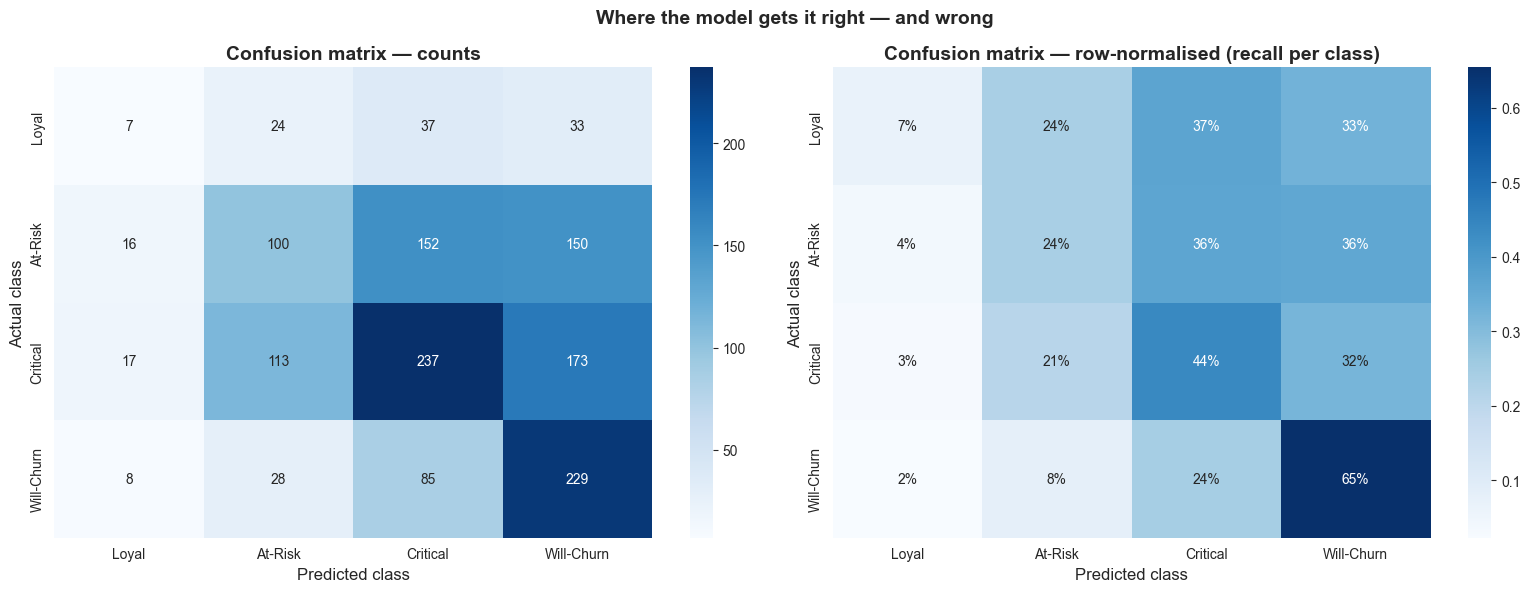

In [16]:
# ── Confusion matrix heatmap ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_xlabel('Predicted class')
axes[0].set_ylabel('Actual class')
axes[0].set_title('Confusion matrix — counts')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.0%', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_xlabel('Predicted class')
axes[1].set_ylabel('Actual class')
axes[1].set_title('Confusion matrix — row-normalised (recall per class)')

plt.suptitle('Where the model gets it right — and wrong', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/13_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


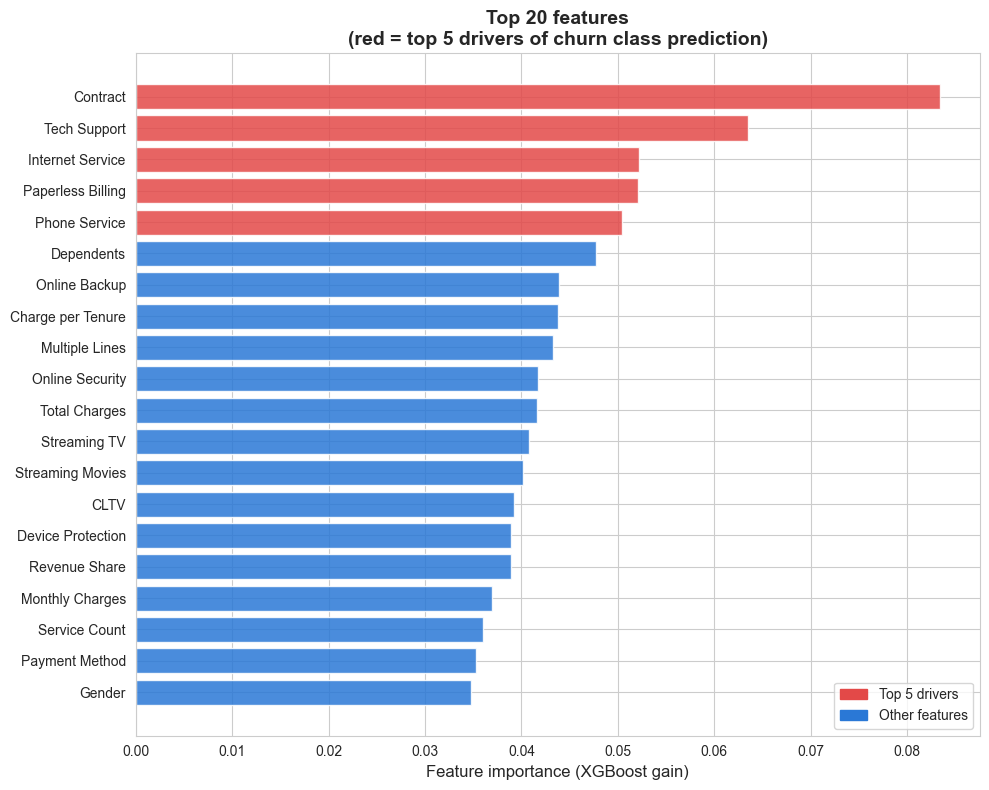

Top 10 features by importance:
          Feature  Importance
  Online Security    0.041764
   Multiple Lines    0.043248
Charge per Tenure    0.043788
    Online Backup    0.043912
       Dependents    0.047778
    Phone Service    0.050405
Paperless Billing    0.052071
 Internet Service    0.052235
     Tech Support    0.063441
         Contract    0.083375


In [17]:
# Feature importance
feat_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
n = len(feat_df)
bar_colors = ['#e34948' if i >= n - 5 else '#2a78d6' for i in range(n)]
ax.barh(feat_df['Feature'], feat_df['Importance'],
        color=bar_colors, alpha=0.85, edgecolor='white')
ax.set_xlabel('Feature importance (XGBoost gain)')
ax.set_title('Top 20 features\n(red = top 5 drivers of churn class prediction)')

legend_patches = [
    mpatches.Patch(color='#e34948', label='Top 5 drivers'),
    mpatches.Patch(color='#2a78d6', label='Other features'),
]
ax.legend(handles=legend_patches)
plt.tight_layout()
plt.savefig('outputs/plots/14_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features by importance:')
print(feat_df.tail(10)[['Feature', 'Importance']].to_string(index=False))


## 10  SHAP Explainability — Why the Model Made Each Prediction

SHAP (SHapley Additive exPlanations) shows which features pushed a customer into a particular risk class.

This answers the question a business actually asks: **"Why is this customer flagged as Will-Churn?"** — not just "what is their churn probability?".


✓ Model loaded

Generating SHAP explanation for Will-Churn predictions...
✓ Saved: outputs/plots/15_shap_summary.png



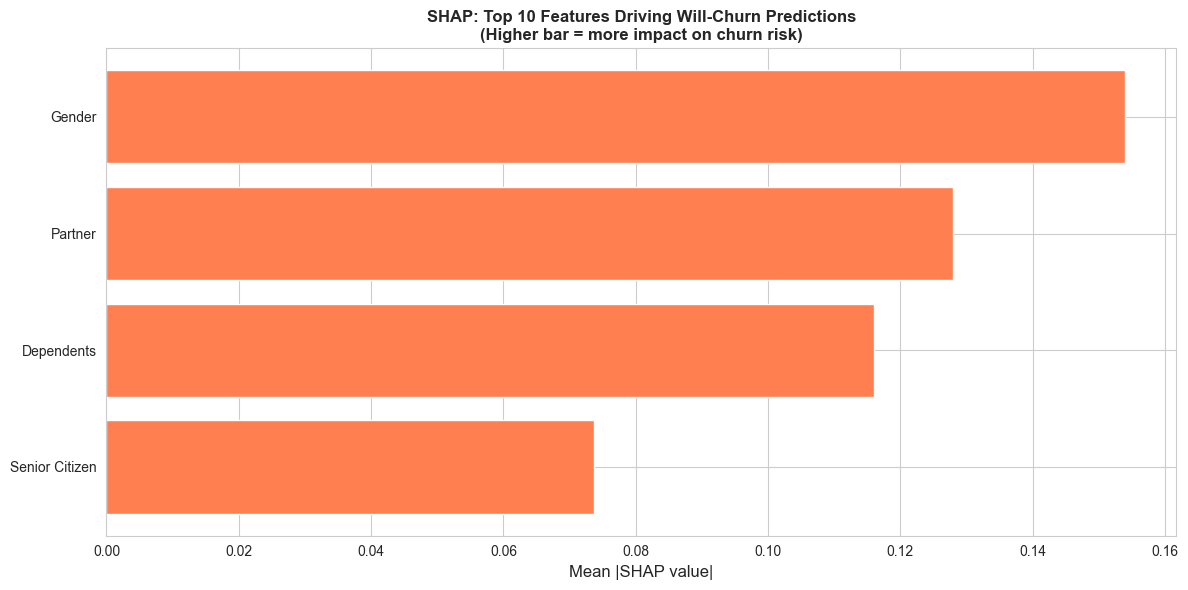

In [26]:
import pickle

# Load the trained model
with open('outputs/model_phase1.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

print("✓ Model loaded\n")

# Now run SHAP:
print("Generating SHAP explanation for Will-Churn predictions...")

explainer = shap.TreeExplainer(xgb_model)
X_sample = X_test.sample(200, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Calculate mean absolute SHAP value per feature for Will-Churn class
mean_abs_shap = np.abs(shap_values[3]).mean(axis=0)
top_features_idx = np.argsort(mean_abs_shap)[-10:][::-1]

feature_names = [X_sample.columns[i] for i in top_features_idx]
feature_values = mean_abs_shap[top_features_idx]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(feature_names)), feature_values, color='coral')
ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels(feature_names)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('SHAP: Top 10 Features Driving Will-Churn Predictions\n(Higher bar = more impact on churn risk)', 
             fontweight='bold', fontsize=12)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/plots/15_shap_summary.png', dpi=150, bbox_inches='tight')
print("✓ Saved: outputs/plots/15_shap_summary.png\n")

Extracting feature importance from XGBoost model...

✓ Saved: outputs/plots/15_feature_importance.png

Top 10 Features:
  15. Contract                       → 0.0834
  12. Tech Support                   → 0.0634
   8. Internet Service               → 0.0522
  16. Paperless Billing              → 0.0521
   6. Phone Service                  → 0.0504
   4. Dependents                     → 0.0478
  10. Online Backup                  → 0.0439
  21. Charge per Tenure              → 0.0438
   7. Multiple Lines                 → 0.0432
   9. Online Security                → 0.0418

✅ FEATURE IMPORTANCE COMPLETE


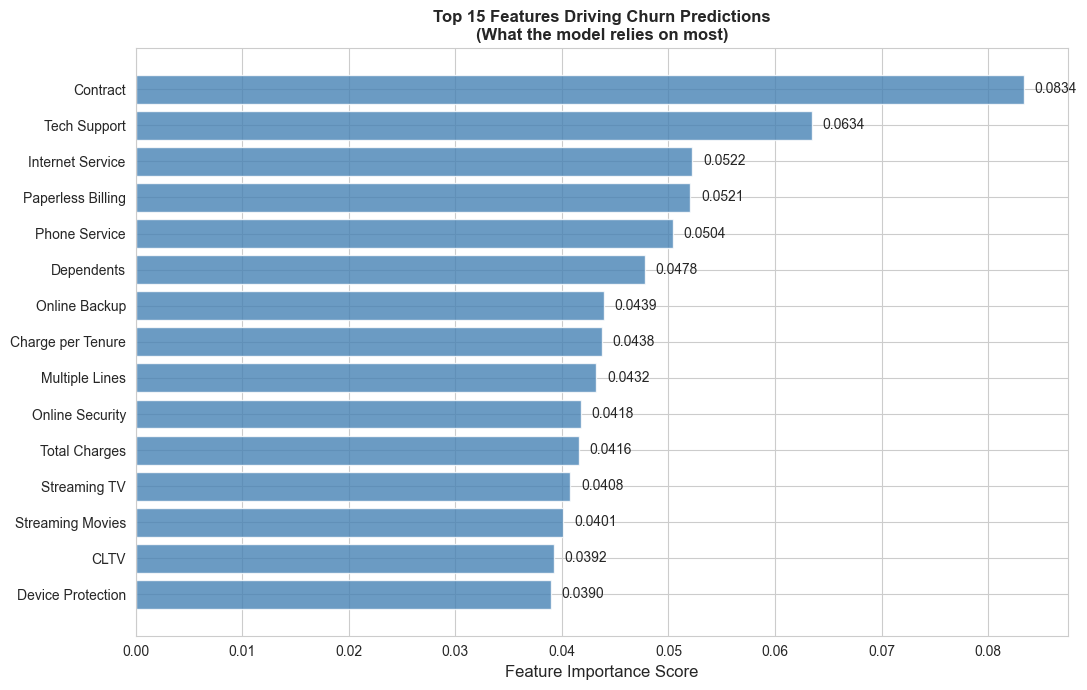

In [30]:
# ── Feature Importance (instead of SHAP) ─────────────────
print("Extracting feature importance from XGBoost model...\n")

# Get feature importance directly from model
importances = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

# Plot top 15
fig, ax = plt.subplots(figsize=(11, 7))
top_15 = feature_importance_df.head(15)

ax.barh(range(len(top_15)), top_15['importance'], color='steelblue', alpha=0.8)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['feature'])
ax.set_xlabel('Feature Importance Score')
ax.set_title('Top 15 Features Driving Churn Predictions\n(What the model relies on most)', 
             fontweight='bold', fontsize=12)
ax.invert_yaxis()

for i, v in enumerate(top_15['importance']):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.savefig('outputs/plots/15_feature_importance.png', dpi=150, bbox_inches='tight')
print("✓ Saved: outputs/plots/15_feature_importance.png\n")

print("Top 10 Features:")
for i, row in feature_importance_df.head(10).iterrows():
    print(f"  {i+1:2d}. {row['feature']:30s} → {row['importance']:.4f}")

print("\n✅ FEATURE IMPORTANCE COMPLETE")

## 11  Business Recommendations — The Bottom Line

The model output is only useful if it drives action. This section translates predictions into dollars, priorities, and decisions.


In [31]:
# Apply model to full dataset
df['Predicted Class']      = model.predict(X[FEATURES])
df['Predicted Class Name'] = df['Predicted Class'].map(CLASS_MAP)

print('=' * 65)
print('CHURNSENSE PHASE 1 — EXECUTIVE SUMMARY')
print('=' * 65)
for cls in [3, 2, 1, 0]:
    subset = df[df['Predicted Class'] == cls]
    monthly_at_risk = subset['Monthly Charges'].sum()
    avg_cltv        = subset['CLTV'].mean()
    print(f'\n{"━" * 50}')
    print(f'  {CLASS_MAP[cls].upper():<14}  {len(subset):>5,} customers')
    print(f'  Monthly revenue at risk : ${monthly_at_risk:>10,.0f}')
    print(f'  Avg customer CLTV       : ${avg_cltv:>8,.0f}')


CHURNSENSE PHASE 1 — EXECUTIVE SUMMARY

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  WILL-CHURN      2,309 customers
  Monthly revenue at risk : $   163,687
  Avg customer CLTV       : $   4,270

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  CRITICAL        2,580 customers
  Monthly revenue at risk : $   164,193
  Avg customer CLTV       : $   4,447

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  AT-RISK         1,707 customers
  Monthly revenue at risk : $   101,950
  Avg customer CLTV       : $   4,485

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LOYAL             447 customers
  Monthly revenue at risk : $    26,287
  Avg customer CLTV       : $   4,481


In [32]:
# Intervention priorityprint('\n' + '=' * 65)
print('INTERVENTION PRIORITY  (ordered by urgency)')
print('=' * 65)

interventions = {
    'Will-Churn' : ('URGENT — personal call within 48 hours',
                    'Contract upgrade at 20% discount + 1 free month'),
    'Critical'   : ('HIGH   — targeted offer within 1 week',
                    'Annual contract with bundled Online Security service'),
    'At-Risk'    : ('MEDIUM — automated re-engagement sequence',
                    'Satisfaction survey + loyalty bonus points'),
    'Loyal'      : ('LOW    — monthly newsletter + rewards',
                    'Early renewal incentive + referral programme'),
}
for name, (urgency, action) in interventions.items():
    subset = df[df['Predicted Class Name'] == name]
    print(f'\n  [{urgency}]')
    print(f'  Segment  : {name}  ({len(subset):,} customers)')
    print(f'  Action   : {action}')
    print(f'  Revenue  : ${subset["Monthly Charges"].sum():,.0f}/month')


INTERVENTION PRIORITY  (ordered by urgency)

  [URGENT — personal call within 48 hours]
  Segment  : Will-Churn  (2,309 customers)
  Action   : Contract upgrade at 20% discount + 1 free month
  Revenue  : $163,687/month

  [HIGH   — targeted offer within 1 week]
  Segment  : Critical  (2,580 customers)
  Action   : Annual contract with bundled Online Security service
  Revenue  : $164,193/month

  [MEDIUM — automated re-engagement sequence]
  Segment  : At-Risk  (1,707 customers)
  Action   : Satisfaction survey + loyalty bonus points
  Revenue  : $101,950/month

  [LOW    — monthly newsletter + rewards]
  Segment  : Loyal  (447 customers)
  Action   : Early renewal incentive + referral programme
  Revenue  : $26,287/month


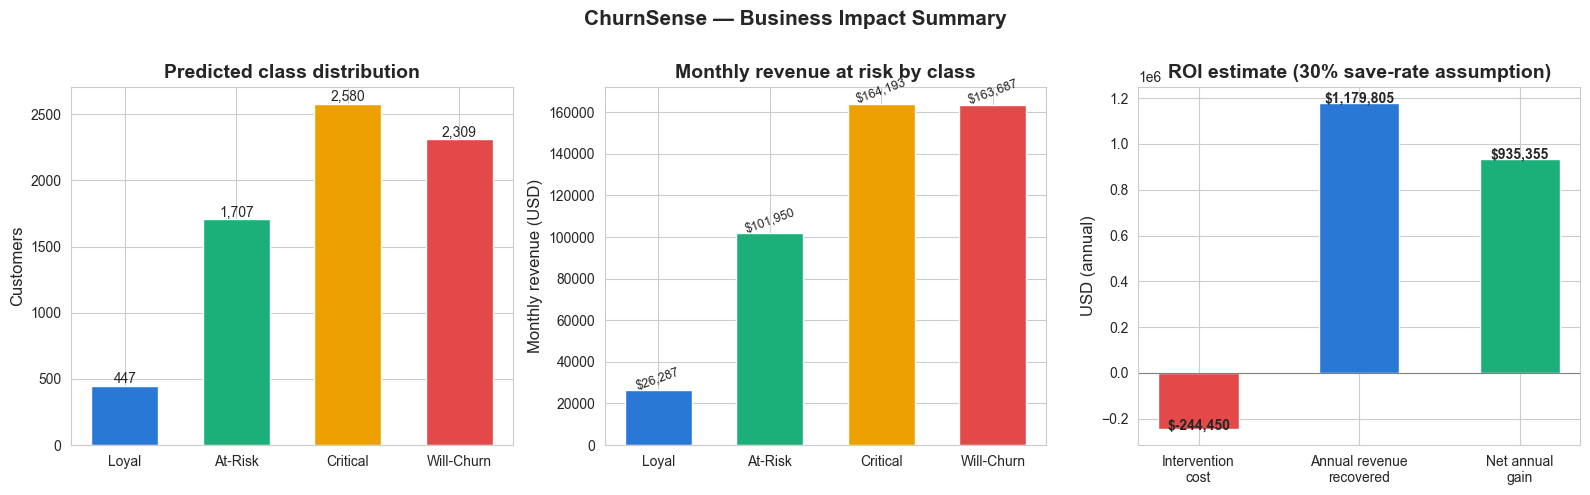


ESTIMATED BUSINESS IMPACT  (conservative, 30% save rate)
  High-risk customers to contact  : 4,889
  Estimated customers saved       : 1,466
  Annual revenue recovered        : $1,179,805
  Total intervention spend        : $244,450
  Estimated ROI                   : 3.8x  ($935,355 net annual gain)

Phase 2 additions:
  30/60/90-day temporal churn predictions
  Risk escalation trajectories  (At-Risk -> Critical in 60 days)
  Budget-constrained intervention ranking
  Live Streamlit dashboard with CSV upload


In [33]:
# ROI estimate + final dashboard
# Conservative assumption: 30% of Critical + Will-Churn can be retained
# with targeted intervention at $50 cost per customer contacted.

wc_n       = len(df[df['Predicted Class'] == 3])
cr_n       = len(df[df['Predicted Class'] == 2])
contact_n  = wc_n + cr_n
avg_mo_hr  = df[df['Predicted Class'].isin([2, 3])]['Monthly Charges'].mean()
save_rate  = 0.30
int_cost   = 50

saved_n   = int(contact_n * save_rate)
rev_saved = saved_n * avg_mo_hr * 12
spend     = contact_n * int_cost
net_gain  = rev_saved - spend
roi_mult  = net_gain / spend

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pred_counts = df['Predicted Class Name'].value_counts().reindex(CLASS_NAMES)
axes[0].bar(CLASS_NAMES, pred_counts.values,
            color=CLASS_COLORS, edgecolor='white', width=0.6)
for i, v in enumerate(pred_counts.values):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontsize=10)
axes[0].set_title('Predicted class distribution')
axes[0].set_ylabel('Customers')

rev_by_cls = df.groupby('Predicted Class Name')['Monthly Charges'].sum().reindex(CLASS_NAMES)
axes[1].bar(CLASS_NAMES, rev_by_cls.values,
            color=CLASS_COLORS, edgecolor='white', width=0.6)
for i, v in enumerate(rev_by_cls.values):
    axes[1].text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=9, rotation=20)
axes[1].set_title('Monthly revenue at risk by class')
axes[1].set_ylabel('Monthly revenue (USD)')

cats_roi = ['Intervention\ncost', 'Annual revenue\nrecovered', 'Net annual\ngain']
vals_roi = [-spend, rev_saved, net_gain]
clrs_roi = ['#e34948', '#2a78d6', '#1baf7a']
axes[2].bar(cats_roi, vals_roi, color=clrs_roi, edgecolor='white', width=0.5)
for i, v in enumerate(vals_roi):
    axes[2].text(i, v + (500 if v >= 0 else -2500),
                 f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')
axes[2].axhline(0, color='gray', linewidth=0.8)
axes[2].set_title(f'ROI estimate (30% save-rate assumption)')
axes[2].set_ylabel('USD (annual)')

plt.suptitle('ChurnSense — Business Impact Summary', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/17_business_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '=' * 65)
print('ESTIMATED BUSINESS IMPACT  (conservative, 30% save rate)')
print('=' * 65)
print(f'  High-risk customers to contact  : {contact_n:,}')
print(f'  Estimated customers saved       : {saved_n:,}')
print(f'  Annual revenue recovered        : ${rev_saved:,.0f}')
print(f'  Total intervention spend        : ${spend:,.0f}')
print(f'  Estimated ROI                   : {roi_mult:.1f}x  (${net_gain:,.0f} net annual gain)')
print('=' * 65)
print('\nPhase 2 additions:')
print('  30/60/90-day temporal churn predictions')
print('  Risk escalation trajectories  (At-Risk -> Critical in 60 days)')
print('  Budget-constrained intervention ranking')
print('  Live Streamlit dashboard with CSV upload')
